# Loading csv file into a Dataframe

In [3]:
import pandas as pd
df=pd.read_csv(r"C:\Users\lavan\Downloads\e_learning_dataset.csv")
print(df.head())

  Student_ID Course_ID  Activity_Hours  Completion_Rate  Quiz1_Score  \
0      S0001      C107            13.5            100.0         91.0   
1      S0002      C104             6.3             65.0         79.0   
2      S0003      C108             6.5             89.0         81.0   
3      S0004      C105            10.8             56.0         85.0   
4      S0005      C107             7.6             64.0         81.0   

   Quiz2_Score  Final_Exam      Status  
0         71.0       100.0   Completed  
1         82.0        96.0  Incomplete  
2         70.0        70.0   Completed  
3        100.0        79.0  Incomplete  
4         87.0        75.0  Incomplete  


## 1)Add a new column Overall_Avg = average of Quiz1_Score, Quiz2_Score, and Final_Exam.

In [28]:
# Calculate average across the three columns
df["Overall_Avg"] = df[["Quiz1_Score", "Quiz2_Score", "Final_Exam"]].mean(axis=1)

# Show first 5 rows to verify
print(df[["Student_ID", "Quiz1_Score", "Quiz2_Score", "Final_Exam", "Overall_Avg"]].head())


  Student_ID  Quiz1_Score  Quiz2_Score  Final_Exam  Overall_Avg
0      S0001         91.0         71.0       100.0    87.333333
1      S0002         79.0         82.0        96.0    85.666667
2      S0003         81.0         70.0        70.0    73.666667
3      S0004         85.0        100.0        79.0    88.000000
4      S0005         81.0         87.0        75.0    81.000000


## 2)Convert the Final_Exam column to a NumPy array and calculate its mean and variance.

In [ ]:
import numpy as np

final_exam_np = df["Final_Exam"].to_numpy()

mean_final = np.mean(final_exam_np)
var_final = np.var(final_exam_np)

print("Mean Final Exam Score:", mean_final)
print("Variance of Final Exam Score:", var_final)


Mean Final Exam Score: 77.883
Variance of Final Exam Score: 137.349311


## 3)Compute maximum and minimum Completion_rate

In [4]:
max_completion = df['Completion_Rate'].max()
min_completion = df['Completion_Rate'].min()
print(f"Maximum Completion Rate: {max_completion}")
print(f"Minimum Completion Rate: {min_completion}\n")

Maximum Completion Rate: 100.0
Minimum Completion Rate: 12.0



## 4)find how many students scored above 90 in final exam


In [5]:
students_above_90 = df[df['Final_Exam'] > 90].shape[0]
print(f"Number of students scored above 90 in Final Exam: {students_above_90}\n")

Number of students scored above 90 in Final Exam: 147



## 5)Plot a histogram of Activity_Hours.

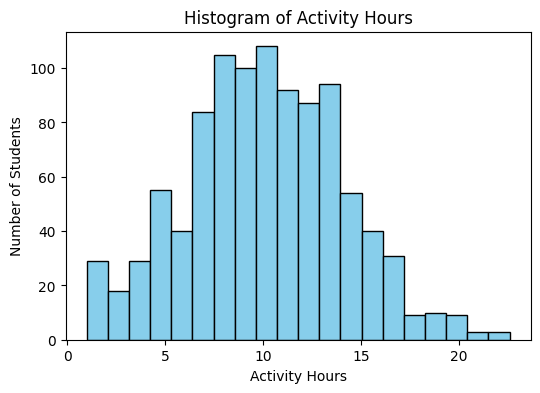

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Activity_Hours"], bins=20, edgecolor="black", color="skyblue")
plt.title("Histogram of Activity Hours")
plt.xlabel("Activity Hours")
plt.ylabel("Number of Students")
plt.show()


## 6)Draw a pie chart of the proportion of "Completed" vs "Incomplete" students.

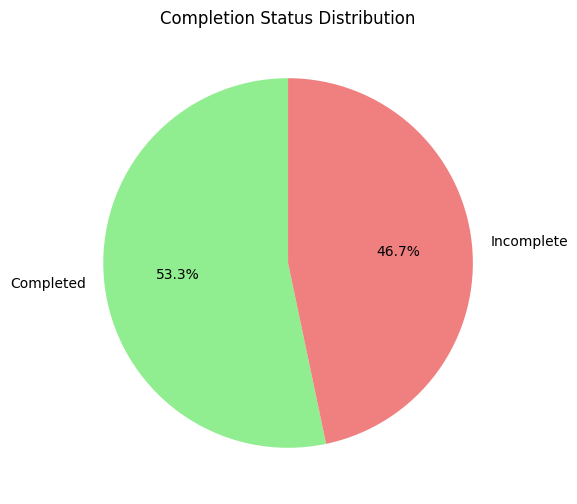

In [ ]:
plt.figure(figsize=(6,6))
df["Status"].value_counts().plot(
    kind="pie", 
    autopct="%1.1f%%", 
    startangle=90, 
    colors=["lightgreen", "lightcoral"]
)
plt.title("Completion Status Distribution")
plt.ylabel("")  # removes default y-label
plt.show()


## 7).Plot histogram of Completion_rate

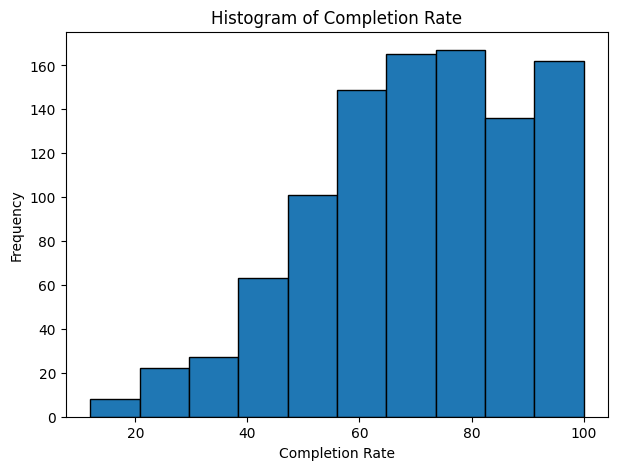

In [8]:
plt.figure(figsize=(7,5))
plt.hist(df['Completion_Rate'], bins=10, edgecolor='black')
plt.title('Histogram of Completion Rate')
plt.xlabel('Completion Rate')
plt.ylabel('Frequency')
plt.show()

## 8)create a barplot of average Final_exam score grouped by status .

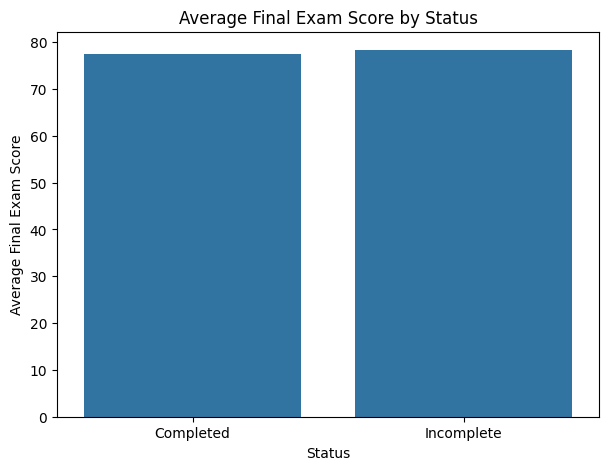

In [11]:
import seaborn as sns
plt.figure(figsize=(7,5))
sns.barplot(x='Status', y='Final_Exam', data=df, estimator='mean', errorbar=None)
plt.title('Average Final Exam Score by Status')
plt.xlabel('Status')
plt.ylabel('Average Final Exam Score')
plt.show()

## 9)Create a heatmap of correlations among numerical columns (Activity_Hours, Completion_Rate, Quiz1_Score, Quiz2_Score, Final_Exam).

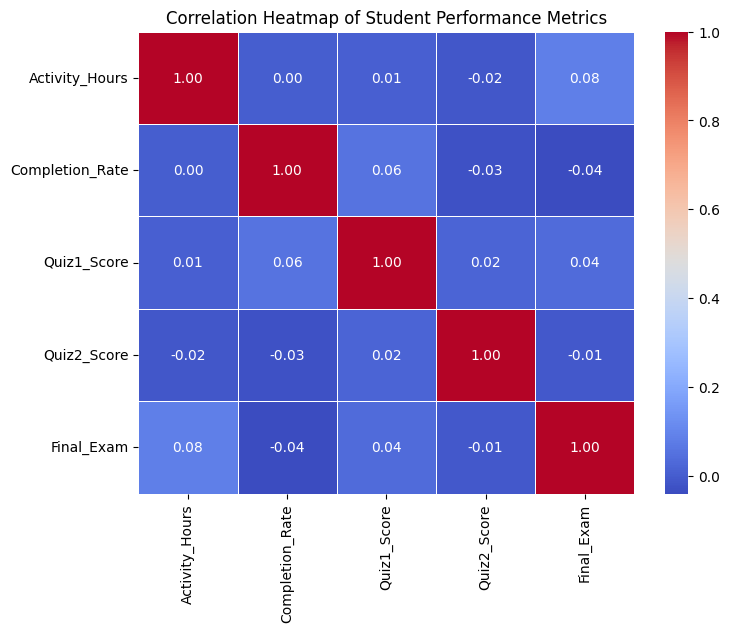

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns to analyze correlation
num_cols = ["Activity_Hours", "Completion_Rate", "Quiz1_Score", "Quiz2_Score", "Final_Exam"]

# Create correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Student Performance Metrics")
plt.show()

## 10)Show a boxplot of Quiz1_Score vs status

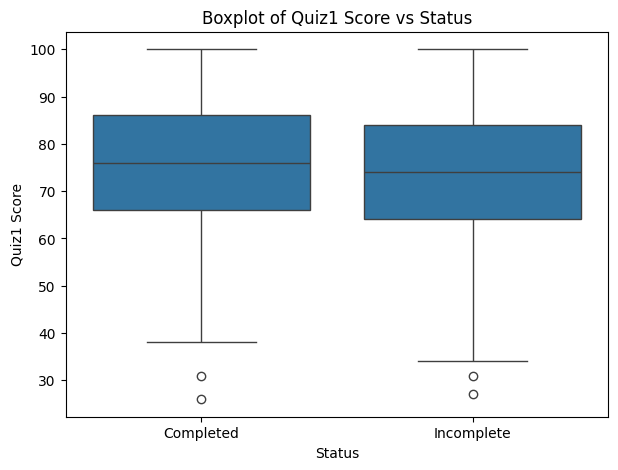

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Status', y='Quiz1_Score', data=df)
plt.title('Boxplot of Quiz1 Score vs Status')
plt.xlabel('Status')
plt.ylabel('Quiz1 Score')
plt.show()